# Day 18: CNN Architectures — VGG Blocks & ResNet Skip Connections

> **Goal:** Learn two foundational CNN design patterns: VGG-style blocks and ResNet's residual connections. Build and train both.

---

## Historical Context

| Year | Model | Key Idea | Depth | ILSVRC Top-5 Error |
|---|---|---|---|---|
| 2014 | **VGG** | Small (3×3) filters stacked deep | 16–19 | 7.3% |
| 2015 | **ResNet** | Skip connections | 152+ | 3.6% |

These ideas are still used in every modern architecture!

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


We reuse the CIFAR-10 data pipeline from Day 17 — same augmentation and normalization:

In [2]:
# Data (same as Day 17)
CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
test_transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])

full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_data  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
train_data, val_data = random_split(full_train, [45000, 5000], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train: 45000, Val: 5000, Test: 10000
Train batches: 352, Val batches: 40, Test batches: 79


---
## Part 1: VGG-Style Blocks

### VGG's Insight
Instead of one big filter (5×5 or 7×7), stack **multiple 3×3** filters:
- Two 3×3 convs have the same receptive field as one 5×5
- Three 3×3 convs = one 7×7
- But with **fewer parameters** and **more non-linearity**!

### VGG Block
```
Conv3×3 → BN → ReLU → Conv3×3 → BN → ReLU → MaxPool2d
```

In [3]:
def vgg_block(in_channels, out_channels, num_convs):
    """A VGG-style block: num_convs × (Conv → BN → ReLU) + MaxPool."""
    layers = []
    for i in range(num_convs):
        layers.extend([
            nn.Conv2d(in_channels if i == 0 else out_channels,
                      out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ])
    layers.append(nn.MaxPool2d(2, 2))
    return nn.Sequential(*layers)


class VGGNet(nn.Module):
    """VGG-style network for CIFAR-10."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            vgg_block(3,   64,  2),   # 32→16
            vgg_block(64,  128, 2),   # 16→8
            vgg_block(128, 256, 2),   # 8→4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # → (256, 1, 1)
            nn.Flatten(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


vgg_model = VGGNet().to(device)
print(vgg_model)
print(f"\nParameters: {sum(p.numel() for p in vgg_model.parameters()):,}")

VGGNet(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplac

---
## Part 2: ResNet — Skip Connections

### The Problem with Deep Networks

Stacking more layers should always help — but in practice, very deep networks perform *worse* (degradation problem). Gradients vanish or explode through many layers.

### ResNet's Solution: Residual Learning

Instead of learning `H(x)` directly, learn the **residual** `F(x) = H(x) - x`, then add it back:

$$\text{output} = F(x) + x$$

This is the **skip connection** (or shortcut). If `F(x)` = 0, the block becomes an identity — so adding layers can never hurt!

```
x ──────────────────┐
│                    │ (skip / shortcut)
├─ Conv → BN → ReLU │
├─ Conv → BN        │
│                    │
└───── + ◄───────────┘
       │
     ReLU
```

In [4]:
class ResidualBlock(nn.Module):
    """A basic residual block with skip connection."""

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # If dimensions change, we need to project the skip connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)  # Skip connection

        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity  # ← The skip connection!
        out = torch.relu(out)

        return out


# Test the block
block = ResidualBlock(64, 64)
x = torch.randn(1, 64, 16, 16)
print(f"Same dims:     {x.shape} → {block(x).shape}")

block2 = ResidualBlock(64, 128, stride=2)
print(f"Change dims:   {x.shape} → {block2(x).shape}")

Same dims:     torch.Size([1, 64, 16, 16]) → torch.Size([1, 64, 16, 16])
Change dims:   torch.Size([1, 64, 16, 16]) → torch.Size([1, 128, 8, 8])


### Building a Complete ResNet

Now we stack multiple residual blocks into a full network. Notice the pattern:
- **Layer 1** keeps the same spatial size (32×32) but establishes 64 channels
- **Layer 2** uses `stride=2` to halve spatial dimensions (32→16) and doubles channels (64→128)
- **Layer 3** halves again (16→8) and doubles channels again (128→256)
- **AdaptiveAvgPool2d(1)** reduces any spatial size to 1×1 — so the classifier doesn't depend on input resolution

In [5]:
class SimpleResNet(nn.Module):
    """A small ResNet for CIFAR-10."""

    def __init__(self, num_classes=10):
        super().__init__()

        # Initial conv
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Residual blocks
        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
        )  # 32×32

        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),  # 32→16
            ResidualBlock(128, 128),
        )

        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),  # 16→8
            ResidualBlock(256, 256),
        )

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


resnet_model = SimpleResNet().to(device)
print(f"SimpleResNet parameters: {sum(p.numel() for p in resnet_model.parameters()):,}")

SimpleResNet parameters: 2,777,674


---
## 3. Train & Compare

In [6]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def run_training(model, name, epochs=30, lr=1e-3):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {"val_acc": []}
    for epoch in range(epochs):
        train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        vl, va = evaluate(model, val_loader, loss_fn, device)
        scheduler.step()
        history["val_acc"].append(va)
        if (epoch+1) % 10 == 0:
            print(f"  {name} Epoch {epoch+1}: Val Acc = {va:.2%}")
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
    print(f"  {name} Test Acc: {test_acc:.2%}")
    return history

Now let's train both models with identical settings and compare. We expect ResNet to win — its skip connections allow gradients to flow more freely, enabling better optimization:

In [7]:
print("Training VGGNet...")
torch.manual_seed(42)
vgg_model = VGGNet().to(device)
h_vgg = run_training(vgg_model, "VGG", epochs=30)

print("\nTraining SimpleResNet...")
torch.manual_seed(42)
resnet_model = SimpleResNet().to(device)
h_resnet = run_training(resnet_model, "ResNet", epochs=30)

Training VGGNet...
  VGG Epoch 10: Val Acc = 83.68%
  VGG Epoch 20: Val Acc = 88.64%
  VGG Epoch 30: Val Acc = 90.32%
  VGG Test Acc: 90.30%

Training SimpleResNet...
  ResNet Epoch 10: Val Acc = 83.14%
  ResNet Epoch 20: Val Acc = 88.70%
  ResNet Epoch 30: Val Acc = 91.54%
  ResNet Test Acc: 91.88%


### Visual Comparison

The plot below shows validation accuracy over epochs. Notice that ResNet typically converges faster and achieves higher accuracy — the skip connections make optimization easier even though both models have similar parameter counts.

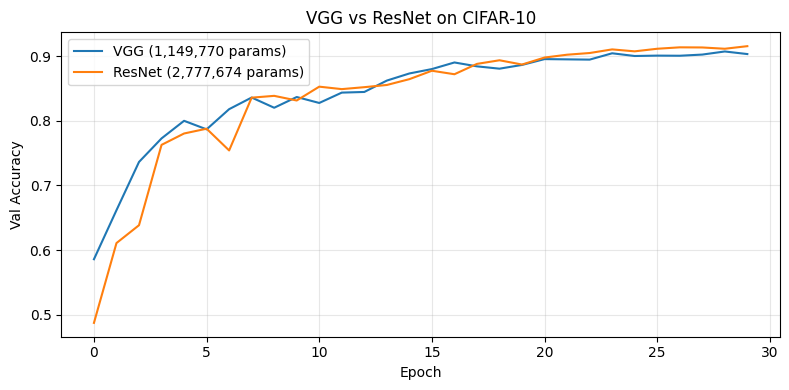

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(h_vgg["val_acc"], label=f"VGG ({sum(p.numel() for p in VGGNet().parameters()):,} params)")
plt.plot(h_resnet["val_acc"], label=f"ResNet ({sum(p.numel() for p in SimpleResNet().parameters()):,} params)")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy")
plt.title("VGG vs ResNet on CIFAR-10")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 🧪 Exercises

### Exercise 1: Deeper VGG
Add a 4th VGG block with 512 channels. Does it help or hurt?

### Exercise 2: Remove skip connections
Modify ResidualBlock to not add the identity (comment out `out += identity`). Train again. What happens?

### Exercise 3: Bottleneck block
Implement a bottleneck residual block: 1×1 (reduce channels) → 3×3 → 1×1 (expand channels). Compare parameter count.

### Exercise 4: Use torchvision ResNet
Load `torchvision.models.resnet18(num_classes=10)` and modify the first conv for 32×32 input. Train on CIFAR-10.

In [ ]:
# Exercise 1–4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **VGG blocks** | Stack multiple 3×3 convs — deeper with fewer params than large kernels |
| **Residual/Skip connection** | `output = F(x) + x` — enables training very deep networks |
| **1×1 projection** | Used when skip connection changes dimensions |
| **Global Average Pooling** | Replaces large FC layers, fewer params |
| **Deeper ≠ better** | Without skip connections, very deep networks degrade |

**Tomorrow:** CNN deep dive — we'll explore feature maps layer by layer and understand what the network has learned.